# Setup D: inclined pipe effective sample size proxy

## 1. Title and purpose

This simulation develops a first-order mechanistic proxy model for **Setup D**, an inclined powder pipe with an NIR diffuse reflectance probe mounted in the lower part of the pipe. The objective is to estimate an **effective sample size proxy** during one spectrum acquisition.

The reported quantity is a **refresh-based proxy effective mass**, denoted $m_{\mathrm{eff,proxy}}$. It assumes renewal of powder in front of the probe over a characteristic axial length of order $d_{\mathrm{probe}}$. It is **not** the exact geometric union of all material contributing photons, and it is intended for **comparative engineering analysis** rather than as a validated independent sample mass.

## 2. Scientific background

### NIR diffuse reflectance analysis of powders

In diffuse reflectance NIR measurements, light enters a powder bed, interacts with particles over a limited depth, and a fraction of the scattered light returns to the detector. The measured spectrum therefore reflects an **optically weighted near-surface volume** rather than the entire bulk stream.

### Why use a simple optical interaction approximation?

For engineering comparisons, it is often useful to approximate the instantaneous optical interaction region with a simple geometric volume. Here, the near-wall optical region at any instant is approximated as a cylinder with:

- cross-sectional area equal to the probe window footprint
- depth equal to an assumed light penetration depth

This simplification ignores depth-dependent photon weighting, scattering anisotropy, particle packing effects, and spectral absorption details, but it provides a practical basis for comparative analysis.

### Probe-flow geometry: perpendicular viewing

In Setup D, the NIR probe is mounted **in the pipe wall** and looks **radially inward** toward the center of the pipe. The powder, meanwhile, flows **axially** along the length of the pipe. These two directions are perpendicular to each other.

At any instant, the probe sees a shallow optical disc of powder pressed against the wall:

- the disc face is the **probe footprint** (a circle of diameter $d_{\mathrm{probe}}$), flush with the inner pipe wall
- the disc depth is the **optical penetration depth** $d_{\mathrm{pen}}$, extending radially inward into the flowing powder

Because the probe looks perpendicular to the flow, powder renewal happens by material sliding **across** the probe window rather than being pushed **into** it. The flow delivers fresh material laterally past the probe footprint, while the light penetrates in the radial direction.

This perpendicular arrangement means three independent length scales govern the first-order model:

| Direction | Physical meaning | Length scale |
|---|---|---|
| **Axial** (along flow) | distance powder travels during acquisition | $v \cdot t_{\mathrm{acq}}$ |
| **Tangential** (in the wall plane) | probe footprint width | $d_{\mathrm{probe}}$ |
| **Radial** (into powder) | light penetration depth | $d_{\mathrm{pen}}$ |

Rather than treating the full acquisition as an exact geometric sweep or exact union of sampled material, the model uses a **first-order renewal approximation**. Powder in front of the probe is assumed to refresh over a characteristic axial length of order $d_{\mathrm{probe}}$, which leads to a **refresh-based proxy** for effective sample mass.

### Why moving powder increases the proxy effective mass during one acquisition

If powder continuously moves past the probe during one acquisition, the optical interaction zone is repeatedly refreshed. Faster renewal means that more powder can contribute to the measurement over the acquisition period. That does not guarantee statistical independence of all material seen by the instrument, but it increases the proxy effective mass available for comparative engineering analysis.

### Why Setup D differs from other geometries

Setup D differs from a **static powder bed** because the material in front of the probe is continuously replaced. It also differs from a **mechanically refreshed geometry such as the spiderwheel** because the refresh mechanism is not imposed by discrete compartments or controlled presentation. Instead, it is driven by gravity-assisted powder transport through a tilted pipe.

### Why a superficial velocity model is useful

A practical first approximation is to connect throughput, bulk density, and pipe cross-sectional area to a **superficial bulk velocity**. This gives a simple estimate of how quickly powder is renewed in front of the probe. In reality, the local flow at the lower wall of a tilted pipe may differ substantially from the cross-sectional average, but the superficial velocity remains a useful baseline for sensitivity analysis and engineering intuition.

In [1]:
# 6. Imports
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# 7. User-defined parameters

pipe_diameter_mm = 65.0  # Pipe internal diameter [mm]
pipe_tilt_deg_from_vertical = 26.5  # Pipe axis tilt from vertical [deg]
pipe_total_height_mm = 340.0  # Total height of the pipe [mm]
pipe_inlet_outlet_displacement_mm = 100.2  # Horizontal displacement from inlet to outlet center [mm]
probe_diameter_mm = 5.0  # NIR probe window diameter [mm]
acquisition_time_s = 1.8  # Spectrum acquisition time [s]

throughput_values_kg_h = list(range(40, 101, 5))  # Throughput sweep [kg/h]
density_values_g_cm3 = [0.4, 0.5, 0.6]  # Bulk density scenarios [g/cm^3]
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)  # Penetration depth sweep [mm]

worked_example_throughput_kg_h = 95.0  # Worked example throughput [kg/h]
worked_example_density_g_cm3 = 0.4  # Worked example bulk density [g/cm^3]

worked_example_penetration_depth_mm = 1.0  # Worked example penetration depth [mm]

In [13]:
pipe_diameter_cm_preview = pipe_diameter_mm / 10.0
pipe_area_cm2_preview = math.pi * (pipe_diameter_cm_preview / 2.0) ** 2
velocity_min_cm_s = (min(throughput_values_kg_h) * 1000.0 / 3600.0) / (
    max(density_values_g_cm3) * pipe_area_cm2_preview
)
velocity_max_cm_s = (max(throughput_values_kg_h) * 1000.0 / 3600.0) / (
    min(density_values_g_cm3) * pipe_area_cm2_preview
)

display(Markdown(
    f"## 3. Setup D device description\n\n"
    f"Setup D is modeled as follows:\n\n"
    f"- pipe internal diameter = **{pipe_diameter_mm:.0f} mm**\n"
    f"- pipe axis tilted **{pipe_tilt_deg_from_vertical} degrees from vertical**\n"
    f"- total height of the pipe = **{pipe_total_height_mm:.0f} mm**\n"
    f"- horizontal displacement from inlet to outlet center = **{pipe_inlet_outlet_displacement_mm} mm**\n"
    f"- powder enters from above and moves **axially** downward toward the outlet\n"
    f"- due to the tilt, powder is expected to slide preferentially along the **lower side of the pipe**\n"
    f"- the NIR probe is mounted **in the lower pipe wall**, looking **radially inward** toward the center of the pipe\n"
    f"- the probe viewing direction is therefore **perpendicular to the powder flow direction**\n"
    f"- the probe window is assumed to be **continuously covered by powder**\n"
    f"- the effective sample size proxy therefore depends primarily on **powder renewal in front of the probe**\n\n"
    f"### Probe mounting and viewing geometry\n\n"
    f"The probe is embedded in the pipe wall so that its window is flush with the inner wall surface. "
    f"The probe looks **radially inward** from the wall toward the center of the pipe. The powder flows "
    f"**axially** along the length of the pipe under gravity. These two directions are perpendicular.\n\n"
    f"At any instant, the probe sees a shallow optical disc of powder:\n\n"
    f"- the disc **face** is the probe window circle ({probe_diameter_mm} mm diameter), lying in the plane of the inner wall\n"
    f"- the disc **depth** is the optical penetration depth, extending radially inward into the powder stream\n\n"
    f"Powder renewal occurs by material sliding **across** the probe window in the axial direction, "
    f"not by being pushed **into** the probe in the radial direction. The light penetrates radially into the "
    f"powder, while fresh material is delivered axially. These two processes are orthogonal.\n\n"
    f"This simulation uses a **first-order mechanistic proxy model**. The {pipe_tilt_deg_from_vertical} degree tilt "
    f"is included as part of the physical setup description and qualitative interpretation, but the base model still "
    f"estimates renewal from the total throughput, bulk density, and full pipe cross-sectional area.\n\n"
    f"### Powder state at the probe window\n\n"
    f"The physical state of the powder in front of the probe affects both the optical measurement and the meaning of "
    f"the effective sample size proxy.\n\n"
    f"**Flow regime.** At {pipe_tilt_deg_from_vertical} degrees from vertical, the gravitational component along the pipe axis is "
    f"approximately g*cos(theta) = 8.8 m/s^2, while the transverse component pushing powder toward the lower wall is "
    f"approximately g*sin(theta) = 4.4 m/s^2. Across the modeled sweep, the superficial velocity is approximately "
    f"{velocity_min_cm_s:.2f}-{velocity_max_cm_s:.2f} cm/s, which is consistent with a slow, dense-phase sliding regime rather "
    f"than a dilute suspension or fast pneumatic transport.\n\n"
    f"**Packing state.** Because the powder slides under gravity rather than being pneumatically conveyed or mechanically agitated, "
    f"the material in front of the probe is expected to be in a relatively dense, settled state. This is closer to a loosely packed bed "
    f"than to an aerated or fluidized condition. The powder layer at the probe window is therefore better described as a gently moving packed "
    f"or semi-packed layer.\n\n"
    f"**Wall contact and coverage.** The transverse gravity component ensures that powder is pressed against the lower wall where the "
    f"probe is mounted. At typical operating throughputs the probe window is expected to remain continuously covered. At very low "
    f"throughputs, however, intermittent or slug-like flow could occur, leading to periods of partial coverage or temporary exposure "
    f"of the probe window. The model does not account for such intermittent behavior.\n\n"
    f"**Compaction and consolidation.** In an inclined pipe of this length, the overburden pressure from the column of material above "
    f"the probe may cause mild consolidation of the powder layer near the lower wall. The local bulk density at the probe could therefore "
    f"be slightly higher than the nominal bulk density used in the model. This effect is expected to be small for a {pipe_total_height_mm:.0f} mm pipe "
    f"at moderate throughputs.\n\n"
    f"**Shear and velocity profile.** The flow velocity profile across the pipe cross-section is not uniform. Material near the lower "
    f"wall may move more slowly than the average superficial velocity due to wall friction, while material on the free surface of the "
    f"flowing layer may move faster. The probe therefore sees the slower-moving fraction, which could reduce the effective renewal rate "
    f"compared to the superficial velocity estimate.\n\n"
    f"**Aeration and de-aeration.** If the powder is fed from a hopper or feeder that introduces some air, it may enter the pipe in a "
    f"partially aerated state. As it travels through the pipe, gravity and compaction tend to de-aerate the material. By the time it "
    f"reaches the probe, the powder is likely closer to a tapped or settled condition than to an aerated one.\n\n"
    f"**Implications for the model.** These considerations suggest that the superficial velocity used in the base model may overestimate "
    f"the local renewal rate at the probe position, because the probe sits in a slower-moving wall region with denser packing. A future "
    f"refinement could introduce a wall velocity correction factor or an effective flowing-layer model to account for this."
))

## 3. Setup D device description

Setup D is modeled as follows:

- pipe internal diameter = **65 mm**
- pipe axis tilted **26.5 degrees from vertical**
- total height of the pipe = **340 mm**
- horizontal displacement from inlet to outlet center = **100.2 mm**
- powder enters from above and moves **axially** downward toward the outlet
- due to the tilt, powder is expected to slide preferentially along the **lower side of the pipe**
- the NIR probe is mounted **in the lower pipe wall**, looking **radially inward** toward the center of the pipe
- the probe viewing direction is therefore **perpendicular to the powder flow direction**
- the probe window is assumed to be **continuously covered by powder**
- the effective sample size proxy therefore depends primarily on **powder renewal in front of the probe**

### Probe mounting and viewing geometry

The probe is embedded in the pipe wall so that its window is flush with the inner wall surface. The probe looks **radially inward** from the wall toward the center of the pipe. The powder flows **axially** along the length of the pipe under gravity. These two directions are perpendicular.

At any instant, the probe sees a shallow optical disc of powder:

- the disc **face** is the probe window circle (5.0 mm diameter), lying in the plane of the inner wall
- the disc **depth** is the optical penetration depth, extending radially inward into the powder stream

Powder renewal occurs by material sliding **across** the probe window in the axial direction, not by being pushed **into** the probe in the radial direction. The light penetrates radially into the powder, while fresh material is delivered axially. These two processes are orthogonal.

This simulation uses a **first-order mechanistic proxy model**. The 26.5 degree tilt is included as part of the physical setup description and qualitative interpretation, but the base model still estimates renewal from the total throughput, bulk density, and full pipe cross-sectional area.

### Powder state at the probe window

The physical state of the powder in front of the probe affects both the optical measurement and the meaning of the effective sample size proxy.

**Flow regime.** At 26.5 degrees from vertical, the gravitational component along the pipe axis is approximately g*cos(theta) = 8.8 m/s^2, while the transverse component pushing powder toward the lower wall is approximately g*sin(theta) = 4.4 m/s^2. Across the modeled sweep, the superficial velocity is approximately 0.56-2.09 cm/s, which is consistent with a slow, dense-phase sliding regime rather than a dilute suspension or fast pneumatic transport.

**Packing state.** Because the powder slides under gravity rather than being pneumatically conveyed or mechanically agitated, the material in front of the probe is expected to be in a relatively dense, settled state. This is closer to a loosely packed bed than to an aerated or fluidized condition. The powder layer at the probe window is therefore better described as a gently moving packed or semi-packed layer.

**Wall contact and coverage.** The transverse gravity component ensures that powder is pressed against the lower wall where the probe is mounted. At typical operating throughputs the probe window is expected to remain continuously covered. At very low throughputs, however, intermittent or slug-like flow could occur, leading to periods of partial coverage or temporary exposure of the probe window. The model does not account for such intermittent behavior.

**Compaction and consolidation.** In an inclined pipe of this length, the overburden pressure from the column of material above the probe may cause mild consolidation of the powder layer near the lower wall. The local bulk density at the probe could therefore be slightly higher than the nominal bulk density used in the model. This effect is expected to be small for a 340 mm pipe at moderate throughputs.

**Shear and velocity profile.** The flow velocity profile across the pipe cross-section is not uniform. Material near the lower wall may move more slowly than the average superficial velocity due to wall friction, while material on the free surface of the flowing layer may move faster. The probe therefore sees the slower-moving fraction, which could reduce the effective renewal rate compared to the superficial velocity estimate.

**Aeration and de-aeration.** If the powder is fed from a hopper or feeder that introduces some air, it may enter the pipe in a partially aerated state. As it travels through the pipe, gravity and compaction tend to de-aerate the material. By the time it reaches the probe, the powder is likely closer to a tapped or settled condition than to an aerated one.

**Implications for the model.** These considerations suggest that the superficial velocity used in the base model may overestimate the local renewal rate at the probe position, because the probe sits in a slower-moving wall region with denser packing. A future refinement could introduce a wall velocity correction factor or an effective flowing-layer model to account for this.

## 4. Model assumptions

The base model uses the following assumptions:

- the instantaneous optical sampling region is approximated as a cylinder with volume $A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}$
- the probe window is fully covered by powder at all times
- powder renewal at the probe is approximated by a **first-order renewal approximation** with characteristic axial length of order $d_{\mathrm{probe}}$
- the renewal rate is derived from a **bulk superficial velocity** computed from throughput, density, and full pipe cross-sectional area
- bulk density is constant and spatially uniform within each scenario
- no explicit blocking events occur
- no recirculation correction is included
- local wall velocity may differ from average superficial velocity, but that difference is ignored in the base model
- the powder at the probe is assumed to be in a dense-phase, gravity-driven sliding regime rather than an aerated or fluidized state
- de-aeration during transit through the pipe is assumed but not explicitly modeled
- velocity profiles across the pipe cross-section are not resolved; the superficial velocity represents a bulk average
- the output is a **refresh-based proxy effective mass** intended for comparative engineering analysis, not a validated independent sample mass

These assumptions intentionally favor transparency and internal consistency over full optical or granular-flow realism.

## 5. Mathematical model

Internal units used throughout the simulation are:

- geometry in **cm**
- area in **cm^2**
- volume in **cm^3**
- time in **s**
- density in **g/cm^3**
- throughput entered in **kg/h** and converted internally to **g/s**
- penetration depth entered in **mm** and converted internally to **cm**
- final reported proxy effective sample masses in **mg**

### Geometric directions at the probe

The probe is mounted in the pipe wall, looking **radially inward**. The powder flows **axially** past the probe. The model uses three perpendicular directions:

| Direction | Symbol | Physical meaning |
|---|---|---|
| **Axial** (along flow) | $v \cdot t_{\mathrm{acq}}$ | distance powder travels during acquisition |
| **Tangential** (in the wall plane) | $d_{\mathrm{probe}}$ | probe footprint width |
| **Radial** (into powder) | $d_{\mathrm{pen}}$ | light penetration depth from wall into powder |

At any single instant, the probe sees a shallow optical disc of powder with face area $A_{\mathrm{probe}}$ and radial depth $d_{\mathrm{pen}}$. Over a finite acquisition, the model does **not** claim that the sampled material is an exact geometric sweep or an exact union. Instead, it uses a **first-order renewal approximation** in which the near-wall powder in front of the probe is refreshed over a characteristic axial length of order $d_{\mathrm{probe}}$.

### Pipe and flow quantities

Pipe cross-sectional area:

$$
A_{\mathrm{pipe}} = \pi \left(\frac{d_{\mathrm{pipe}}}{2}\right)^2
$$

Mass flow conversion:

$$
\dot{m}_{\mathrm{g/s}} = \dot{m}_{\mathrm{kg/h}} \cdot \frac{1000}{3600}
$$

Superficial velocity (axial direction):

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

Units: $[\mathrm{g/s}] / ([\mathrm{g/cm^3}] [\mathrm{cm^2}]) = [\mathrm{cm/s}]$.

This is the cross-sectional average axial velocity of the powder along the pipe. In this notebook it is used only as a first-order renewal driver.

**Worked-example check** ($\dot{m} = 95\;\mathrm{kg/h}$, $\rho = 0.4\;\mathrm{g/cm^3}$, $d_{\mathrm{pipe}} = 65\;\mathrm{mm}$):

| Step | Value | Unit |
|---|---|---|
| $\dot{m}$ | $95 \times 1000 / 3600 = 26.3889$ | g/s |
| $A_{\mathrm{pipe}}$ | $\pi (6.5/2)^2 = 33.1831$ | cm^2 |
| $\rho \cdot A_{\mathrm{pipe}}$ | $0.4 \times 33.1831 = 13.2732$ | g/cm |
| $v = \dot{m} / (\rho \cdot A_{\mathrm{pipe}})$ | $26.3889 / 13.2732 = 1.9882$ | cm/s |

### Instantaneous optical mass

Probe footprint area:

$$
A_{\mathrm{probe}} = \pi \left(\frac{d_{\mathrm{probe}}}{2}\right)^2
$$

Instantaneous optical mass:

$$
m_{\mathrm{opt}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

This is the instantaneous optically weighted mass adjacent to the probe under the cylindrical optical-volume approximation.

### Refresh factor

The first-order renewal approximation assumes that the powder in front of the probe is refreshed when material advances by a characteristic axial length of order $d_{\mathrm{probe}}$. The corresponding refresh factor during one acquisition is:

$$
N_{\mathrm{refresh}} = \frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}
$$

This is a renewal-based proxy, not an exact count of independent packets of powder.

### Proxy effective sample mass

The proxy effective sample mass is defined as:

$$
m_{\mathrm{eff,proxy}} = m_{\mathrm{opt}} \cdot N_{\mathrm{refresh}}
$$

Combining the expressions gives:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \left(\frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}\right)
$$

Interpretation of this expression:

- it is a **first-order mechanistic proxy model**
- it assumes renewal of powder over a characteristic length scale of order $d_{\mathrm{probe}}$
- it is **not** the exact geometric union of sampled material
- it is intended for **comparative engineering analysis**

### Convective reference mass-flow proxy

For comparison, the notebook also reports:

$$
m_{\mathrm{passed}} = \rho \cdot v \cdot A_{\mathrm{probe}} \cdot t_{\mathrm{acq}}
$$

This quantity is retained only as a **convective reference mass-flow proxy** based on the same superficial-velocity model. It should **not** be interpreted as a literal exact convected slab or as an exact geometric union of the material seen by the instrument.

Under the same proxy assumptions:

$$
m_{\mathrm{eff,proxy}} = m_{\mathrm{passed}} \cdot \frac{d_{\mathrm{pen}}}{d_{\mathrm{probe}}}
$$

The ratio above is an algebraic consequence of the proxy model, not a statement about exact geometric sampling.

### Density cancellation within this model

The superficial velocity relation is:

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

Substituting into the proxy effective-mass expression gives:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \left(\frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}\right)
$$

$$
m_{\mathrm{eff,proxy}} = \left(\frac{A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}} \cdot A_{\mathrm{pipe}}}\right) \cdot \dot{m}
$$

In this model, the density terms cancel exactly. That cancellation is **model-dependent**: it follows from using the same bulk density in both the instantaneous optical mass and the superficial-velocity approximation.

In [4]:
# 8. Helper functions

def _validate_positive(value, name):
    """Raise a ValueError if value is not strictly positive."""
    if value <= 0:
        raise ValueError(f'{name} must be positive; received {value!r}.')


def mm_to_cm(mm):
    """Convert millimeters to centimeters."""
    _validate_positive(mm, 'mm')
    return mm / 10.0


def kg_h_to_g_s(kg_h):
    """Convert mass flow from kilograms per hour to grams per second."""
    _validate_positive(kg_h, 'kg_h')
    return kg_h * 1000.0 / 3600.0


def pipe_cross_section_area_cm2(pipe_diameter_cm):
    """Return pipe cross-sectional area in cm^2."""
    _validate_positive(pipe_diameter_cm, 'pipe_diameter_cm')
    radius_cm = pipe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def probe_area_cm2(probe_diameter_cm):
    """Return probe footprint area in cm^2."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    radius_cm = probe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm):
    """Estimate superficial bulk velocity in the pipe in cm/s."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    throughput_g_s = kg_h_to_g_s(kg_h=throughput_kg_h)
    area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
    return throughput_g_s / (density_g_cm3 * area_cm2)


def optical_volume_cm3(probe_diameter_cm, penetration_depth_cm):
    """Return static optical interaction volume in cm^3."""
    _validate_positive(penetration_depth_cm, 'penetration_depth_cm')
    return probe_area_cm2(probe_diameter_cm) * penetration_depth_cm


def optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Return instantaneous optical mass in grams."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    return density_g_cm3 * optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)


def crossing_time_s(probe_diameter_cm, velocity_cm_s):
    """Return time for material to move one characteristic probe diameter in seconds."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return probe_diameter_cm / velocity_cm_s


def passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return the convective reference volume-flow proxy during one acquisition in cm^3."""
    _validate_positive(acquisition_time_s, 'acquisition_time_s')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return velocity_cm_s * probe_area_cm2(probe_diameter_cm) * acquisition_time_s


def passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return the convective reference mass-flow proxy during one acquisition in mg."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    volume_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
    return density_g_cm3 * volume_cm3 * 1000.0


def effective_sample_mass_estimate_mg(
    throughput_kg_h,
    density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
):
    """Return a dictionary of first-order proxy effective-mass quantities."""
    velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
    optical_mass_per_refresh_g = optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm)
    t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
    n_refresh = acquisition_time_s / t_cross_s
    effective_mass_estimate_mg = optical_mass_per_refresh_g * n_refresh * 1000.0  # proxy effective mass

    return {
        'superficial_velocity_cm_s': velocity_cm_s,
        'optical_mass_per_refresh_g': optical_mass_per_refresh_g,
        'crossing_time_s': t_cross_s,
        'n_refresh': n_refresh,
        'effective_sample_mass_estimate_mg': effective_mass_estimate_mg,
    }

In [5]:
display(Markdown(
    f"## 9. Single-case worked example\n\n"
    f"The worked example uses:\n\n"
    f"- throughput = **{worked_example_throughput_kg_h} kg/h**\n"
    f"- density = **{worked_example_density_g_cm3} g/cm^3**\n"
    f"- pipe diameter = **{pipe_diameter_mm:.0f} mm**\n"
    f"- pipe tilt = **{pipe_tilt_deg_from_vertical} degrees from vertical**\n"
    f"- pipe total height = **{pipe_total_height_mm:.0f} mm**\n"
    f"- horizontal displacement = **{pipe_inlet_outlet_displacement_mm} mm**\n"
    f"- probe diameter = **{probe_diameter_mm} mm**\n"
    f"- penetration depth = **{worked_example_penetration_depth_mm} mm**\n"
    f"- acquisition time = **{acquisition_time_s} s**\n\n"
    f"This example should be interpreted as a **first-order mechanistic proxy**. In a real tilted pipe, "
    f"the local velocity at the lower wall may differ from the superficial velocity because the "
    f"flowing layer can be asymmetric and concentrated near the lower side."
))

## 9. Single-case worked example

The worked example uses:

- throughput = **95.0 kg/h**
- density = **0.4 g/cm^3**
- pipe diameter = **65 mm**
- pipe tilt = **26.5 degrees from vertical**
- pipe total height = **340 mm**
- horizontal displacement = **100.2 mm**
- probe diameter = **5.0 mm**
- penetration depth = **1.0 mm**
- acquisition time = **1.8 s**

This example should be interpreted as a **first-order mechanistic proxy**. In a real tilted pipe, the local velocity at the lower wall may differ from the superficial velocity because the flowing layer can be asymmetric and concentrated near the lower side.

In [6]:
pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
penetration_depth_cm = mm_to_cm(worked_example_penetration_depth_mm)

pipe_area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
throughput_g_s = kg_h_to_g_s(worked_example_throughput_kg_h)
velocity_cm_s = superficial_velocity_cm_s(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
)
probe_area_value_cm2 = probe_area_cm2(probe_diameter_cm)
optical_volume_value_cm3 = optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)
optical_mass_value_g = optical_mass_g(
    worked_example_density_g_cm3,
    probe_diameter_cm,
    penetration_depth_cm,
)
crossing_time_value_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
n_refresh_value = acquisition_time_s / crossing_time_value_s
effective_estimate = effective_sample_mass_estimate_mg(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
)
passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
passed_mass_value_mg = passed_mass_mg(
    worked_example_density_g_cm3,
    velocity_cm_s,
    probe_diameter_cm,
    acquisition_time_s,
)

print('Worked example: Setup D first-order renewal proxy')
print(f'Pipe tilt from vertical: {pipe_tilt_deg_from_vertical:.1f} deg')
print(f'Pipe cross-sectional area: {pipe_area_cm2:.4f} cm^2')
print(f'Throughput: {throughput_g_s:.4f} g/s')
print(f'Superficial velocity: {velocity_cm_s:.4f} cm/s')
print(f'Probe area: {probe_area_value_cm2:.6f} cm^2')
print(f'Instantaneous optical volume: {optical_volume_value_cm3:.6f} cm^3')
print(f'Instantaneous optical mass: {optical_mass_value_g * 1000.0:.4f} mg')
print(f'Characteristic crossing time: {crossing_time_value_s:.4f} s')
print(f'Refresh factor during acquisition: {n_refresh_value:.4f}')
print(f"Effective sample size proxy: {effective_estimate['effective_sample_mass_estimate_mg']:.4f} mg")
print(f'Convective reference volume-flow proxy: {passed_volume_value_cm3:.6f} cm^3')
print(f'Convective reference mass-flow proxy: {passed_mass_value_mg:.4f} mg')

Worked example: Setup D first-order renewal proxy
Pipe tilt from vertical: 26.5 deg
Pipe cross-sectional area: 33.1831 cm^2
Throughput: 26.3889 g/s
Superficial velocity: 1.9881 cm/s
Probe area: 0.196350 cm^2
Instantaneous optical volume: 0.019635 cm^3
Instantaneous optical mass: 7.8540 mg
Characteristic crossing time: 0.2515 s
Refresh factor during acquisition: 7.1573
Effective sample size proxy: 56.2130 mg
Convective reference volume-flow proxy: 0.702663 cm^3
Convective reference mass-flow proxy: 281.0651 mg


## 10. Parameter sweep across throughput, density, and penetration depth

The full sweep spans:

- throughput from **40 to 100 kg/h**
- density = **0.4, 0.5, 0.6 g/cm^3**
- penetration depth from **0.1 to 2.0 mm** in 0.1 mm steps
- probe diameter fixed at **5 mm**
- acquisition time fixed at **1.8 s** unless changed in the parameter cell

In [7]:
records = []

pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
pipe_area_cm2_value = pipe_cross_section_area_cm2(pipe_diameter_cm)

for throughput_kg_h in throughput_values_kg_h:
    throughput_g_s = kg_h_to_g_s(throughput_kg_h)
    for density_g_cm3 in density_values_g_cm3:
        velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
        t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
        n_refresh = acquisition_time_s / t_cross_s
        passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
        passed_mass_value_mg = passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s)

        for penetration_depth_mm in penetration_depth_values_mm:
            penetration_depth_cm = mm_to_cm(float(penetration_depth_mm))
            estimate = effective_sample_mass_estimate_mg(
                throughput_kg_h,
                density_g_cm3,
                pipe_diameter_cm,
                probe_diameter_cm,
                penetration_depth_cm,
                acquisition_time_s,
            )
            optical_mass_per_refresh_mg = (
                optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm) * 1000.0
            )

            records.append(
                {
                    'throughput_kg_h': throughput_kg_h,
                    'density_g_cm3': density_g_cm3,
                    'pipe_diameter_mm': pipe_diameter_mm,
                    'pipe_tilt_deg_from_vertical': pipe_tilt_deg_from_vertical,
                    'penetration_depth_mm': float(penetration_depth_mm),
                    'probe_diameter_mm': probe_diameter_mm,
                    'acquisition_time_s': acquisition_time_s,
                    'throughput_g_s': throughput_g_s,
                    'pipe_area_cm2': pipe_area_cm2_value,
                    'superficial_velocity_cm_s': velocity_cm_s,
                    'optical_mass_per_refresh_mg': optical_mass_per_refresh_mg,
                    'crossing_time_s': t_cross_s,
                    'n_refresh': n_refresh,
                    'effective_sample_mass_estimate_mg': estimate['effective_sample_mass_estimate_mg'],
                    'passed_volume_cm3': passed_volume_value_cm3,
                    'passed_mass_mg': passed_mass_value_mg,
                }
            )

results_df = pd.DataFrame(records)
results_df = results_df.sort_values(
    ['density_g_cm3', 'throughput_kg_h', 'penetration_depth_mm'], ignore_index=True
)

print(f'Generated {len(results_df)} modeled scenarios.')


Generated 780 modeled scenarios.


## 11. Results tables

All reported effective sample size values below are **proxy values**, i.e. evaluations of $m_{\mathrm{eff,proxy}}$ from the first-order renewal model.

In [8]:
results_df.head(12).rename(
    columns={
        'effective_sample_mass_estimate_mg': 'effective_sample_mass_proxy_mg',
        'passed_mass_mg': 'convective_reference_mass_proxy_mg',
    }
)

,throughput_kg_h,density_g_cm3,pipe_diameter_mm,pipe_tilt_deg_from_vertical,penetration_depth_mm,probe_diameter_mm,acquisition_time_s,throughput_g_s,pipe_area_cm2,superficial_velocity_cm_s,optical_mass_per_refresh_mg,crossing_time_s,n_refresh,effective_sample_mass_proxy_mg,passed_volume_cm3,convective_reference_mass_proxy_mg
0,40,0.4000,65.0000,26.5000,0.1000,5.0000,1.8000,11.1111,33.1831,0.8371,0.7854,0.5973,3.0136,2.3669,0.2959,118.3432
1,40,0.4000,65.0000,26.5000,0.2000,5.0000,1.8000,11.1111,33.1831,0.8371,1.5708,0.5973,3.0136,4.7337,0.2959,118.3432
2,40,0.4000,65.0000,26.5000,0.3000,5.0000,1.8000,11.1111,33.1831,0.8371,2.3562,0.5973,3.0136,7.1006,0.2959,118.3432
3,40,0.4000,65.0000,26.5000,0.4000,5.0000,1.8000,11.1111,33.1831,0.8371,3.1416,0.5973,3.0136,9.4675,0.2959,118.3432
4,40,0.4000,65.0000,26.5000,0.5000,5.0000,1.8000,11.1111,33.1831,0.8371,3.9270,0.5973,3.0136,11.8343,0.2959,118.3432
5,40,0.4000,65.0000,26.5000,0.6000,5.0000,1.8000,11.1111,33.1831,0.8371,4.7124,0.5973,3.0136,14.2012,0.2959,118.3432
6,40,0.4000,65.0000,26.5000,0.7000,5.0000,1.8000,11.1111,33.1831,0.8371,5.4978,0.5973,3.0136,16.5680,0.2959,118.3432
7,40,0.4000,65.0000,26.5000,0.8000,5.0000,1.8000,11.1111,33.1831,0.8371,6.2832,0.5973,3.0136,18.9349,0.2959,118.3432
8,40,0.4000,65.0000,26.5000,0.9000,5.0000,1.8000,11.1111,33.1831,0.8371,7.0686,0.5973,3.0136,21.3018,0.2959,118.3432
9,40,0.4000,65.0000,26.5000,1.0000,5.0000,1.8000,11.1111,33.1831,0.8371,7.8540,0.5973,3.0136,23.6686,0.2959,118.3432


In [9]:
selected_scenarios = results_df[
    results_df['throughput_kg_h'].isin([40, 70, 100])
    & results_df['density_g_cm3'].isin([0.4, 0.5, 0.6])
    & results_df['penetration_depth_mm'].isin([0.5, 1.0, 2.0])
].copy()

selected_scenarios[
    [
        'throughput_kg_h',
        'density_g_cm3',
        'penetration_depth_mm',
        'superficial_velocity_cm_s',
        'optical_mass_per_refresh_mg',
        'n_refresh',
        'effective_sample_mass_estimate_mg',
        'passed_mass_mg',
    ]
].rename(
    columns={
        'effective_sample_mass_estimate_mg': 'effective_sample_mass_proxy_mg',
        'passed_mass_mg': 'convective_reference_mass_proxy_mg',
    }
).reset_index(drop=True)

,throughput_kg_h,density_g_cm3,penetration_depth_mm,superficial_velocity_cm_s,optical_mass_per_refresh_mg,n_refresh,effective_sample_mass_proxy_mg,convective_reference_mass_proxy_mg
0,40,0.4000,0.5000,0.8371,3.9270,3.0136,11.8343,118.3432
1,40,0.4000,1.0000,0.8371,7.8540,3.0136,23.6686,118.3432
2,40,0.4000,2.0000,0.8371,15.7080,3.0136,47.3373,118.3432
3,70,0.4000,0.5000,1.4649,3.9270,5.2738,20.7101,207.1006
4,70,0.4000,1.0000,1.4649,7.8540,5.2738,41.4201,207.1006
5,70,0.4000,2.0000,1.4649,15.7080,5.2738,82.8402,207.1006
6,100,0.4000,0.5000,2.0928,3.9270,7.5340,29.5858,295.8580
7,100,0.4000,1.0000,2.0928,7.8540,7.5340,59.1716,295.8580
8,100,0.4000,2.0000,2.0928,15.7080,7.5340,118.3432,295.8580
9,40,0.5000,0.5000,0.6697,4.9087,2.4109,11.8343,118.3432


In [10]:
pivot_density_05 = results_df[results_df['density_g_cm3'] == 0.5].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_estimate_mg',
)

pivot_density_06 = results_df[results_df['density_g_cm3'] == 0.6].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_estimate_mg',
)

pivot_density_05.iloc[:8, :6]

throughput_kg_h,40,45,50,55,60,65
penetration_depth_mm,,,,,,
0.1000,2.3669,2.6627,2.9586,3.2544,3.5503,3.8462
0.2000,4.7337,5.3254,5.9172,6.5089,7.1006,7.6923
0.3000,7.1006,7.9882,8.8757,9.7633,10.6509,11.5385
0.4000,9.4675,10.6509,11.8343,13.0178,14.2012,15.3846
0.5000,11.8343,13.3136,14.7929,16.2722,17.7515,19.2308
0.6000,14.2012,15.9763,17.7515,19.5266,21.3018,23.0769
0.7000,16.5680,18.6391,20.7101,22.7811,24.8521,26.9231
0.8000,18.9349,21.3018,23.6686,26.0355,28.4024,30.7692


## 12. Visualization

The plots below report either the **effective sample size proxy** or supporting quantities from the same first-order renewal model.

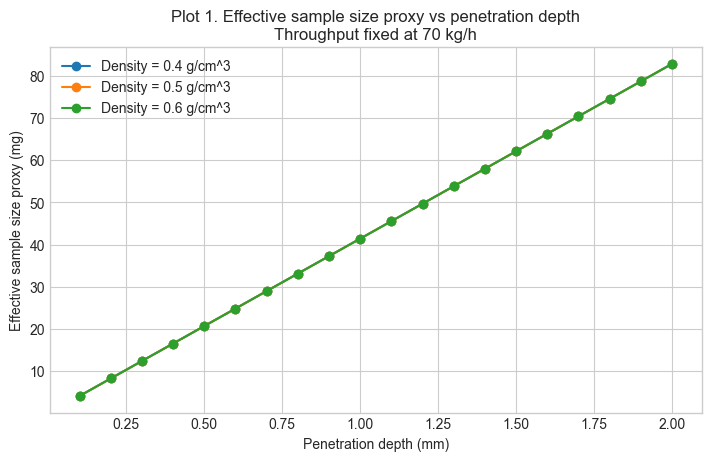

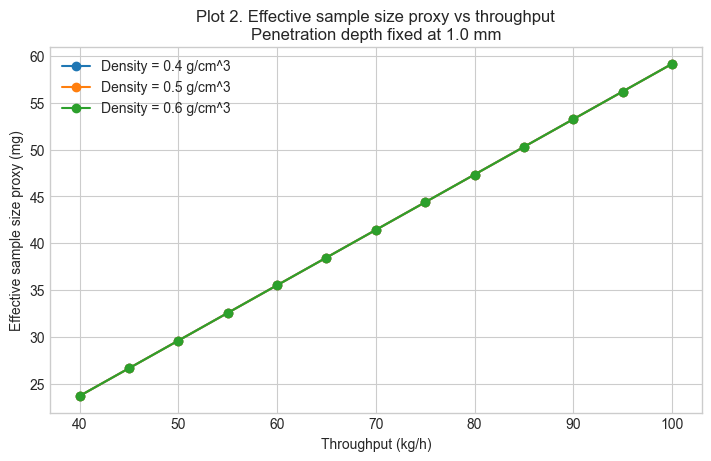

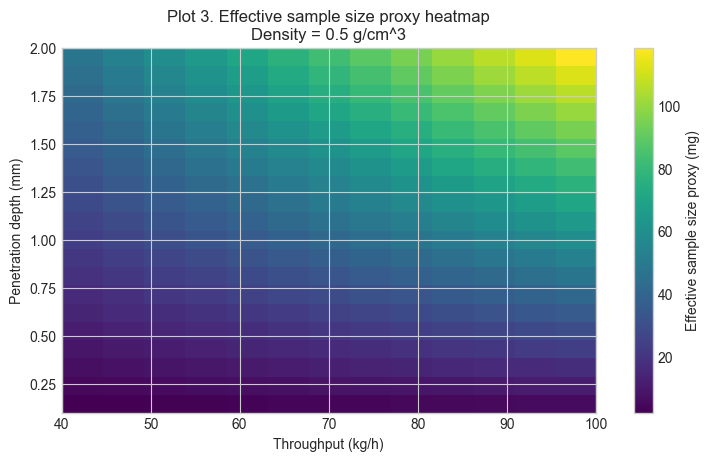

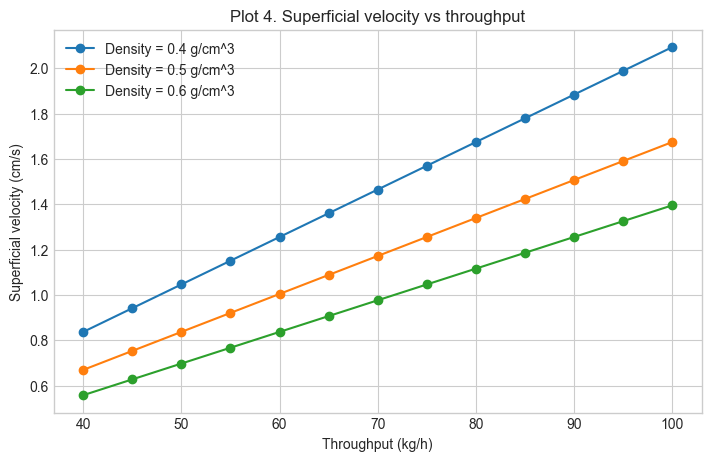

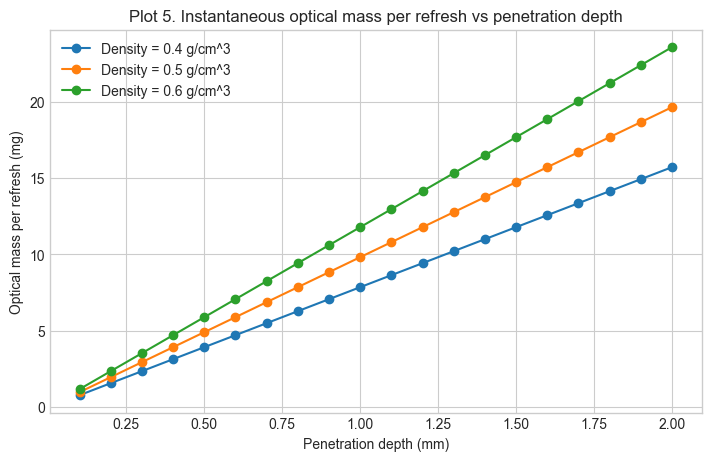

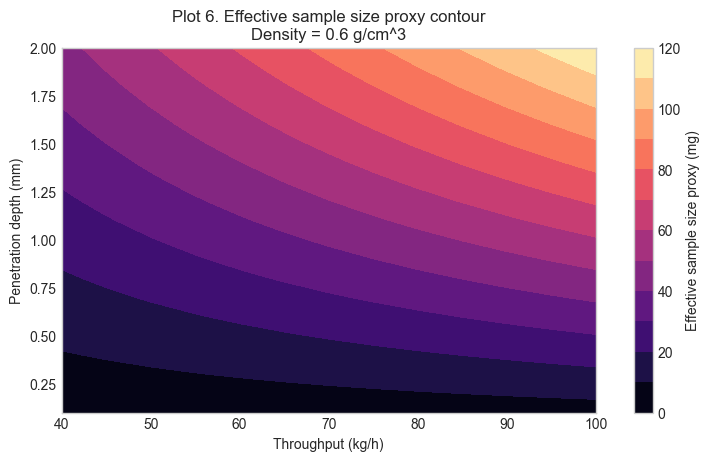

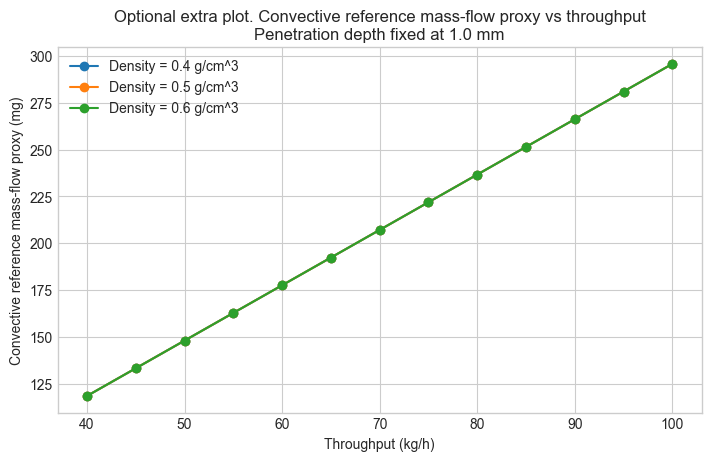

In [11]:
# Plot 1: effective sample size proxy vs penetration depth at fixed throughput
fig_setup_d_plot_01, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot1_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['effective_sample_mass_estimate_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 1. Effective sample size proxy vs penetration depth\nThroughput fixed at 70 kg/h')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.legend()
plt.show()

# Plot 2: effective sample size proxy vs throughput at fixed penetration depth
fig_setup_d_plot_02, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot2_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = plot2_df[plot2_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['effective_sample_mass_estimate_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 2. Effective sample size proxy vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.legend()
plt.show()

# Plot 3: effective sample size proxy heatmap for density 0.5 g/cm^3
fig_setup_d_plot_03, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
im = ax.imshow(
    pivot_density_05.values,
    aspect='auto',
    origin='lower',
    extent=[
        pivot_density_05.columns.min(),
        pivot_density_05.columns.max(),
        pivot_density_05.index.min(),
        pivot_density_05.index.max(),
    ],
    cmap='viridis',
)
ax.set_title('Plot 3. Effective sample size proxy heatmap\nDensity = 0.5 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_03.colorbar(im, ax=ax, label='Effective sample size proxy (mg)')
plt.show()

# Plot 4: superficial velocity vs throughput
fig_setup_d_plot_04, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
velocity_plot_df = (
    results_df[['throughput_kg_h', 'density_g_cm3', 'superficial_velocity_cm_s']]
    .drop_duplicates()
    .sort_values(['density_g_cm3', 'throughput_kg_h'])
)
for density in density_values_g_cm3:
    subset = velocity_plot_df[velocity_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['superficial_velocity_cm_s'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 4. Superficial velocity vs throughput')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Superficial velocity (cm/s)')
ax.legend()
plt.show()

# Plot 5: instantaneous optical mass per refresh vs penetration depth
fig_setup_d_plot_05, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot5_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot5_df[plot5_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['optical_mass_per_refresh_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 5. Instantaneous optical mass per refresh vs penetration depth')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Optical mass per refresh (mg)')
ax.legend()
plt.show()

# Plot 6: effective sample size proxy contour for density 0.6 g/cm^3
fig_setup_d_plot_06, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
T, P = np.meshgrid(pivot_density_06.columns.to_numpy(), pivot_density_06.index.to_numpy())
contour = ax.contourf(T, P, pivot_density_06.values, levels=12, cmap='magma')
ax.set_title('Plot 6. Effective sample size proxy contour\nDensity = 0.6 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_06.colorbar(contour, ax=ax, label='Effective sample size proxy (mg)')
plt.show()

fig_setup_d_passed_mass, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
extra_plot_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = extra_plot_df[extra_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['passed_mass_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Optional extra plot. Convective reference mass-flow proxy vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Convective reference mass-flow proxy (mg)')
ax.legend()
plt.show()

## 13. Interpretation of trends

Several clear trends appear in this first-order proxy model.

- Increasing **density** increases the **instantaneous optical mass** linearly because $m_{\mathrm{opt}} = \rho A_{\mathrm{probe}} d_{\mathrm{pen}}$.
- Increasing **penetration depth** increases the **instantaneous optical mass** linearly because the modeled optical volume grows linearly with depth.
- Increasing **throughput** increases the **superficial velocity** linearly for fixed density and pipe area.
- Increasing superficial velocity increases $N_{\mathrm{refresh}}$ and therefore increases the proxy effective mass during one acquisition.
- The result should be interpreted as a **refresh-based proxy effective mass**, not as a validated independent sampling mass.

### Why density cancels within this model

In this model, density enters in two places that act in opposite directions.

**Effect 1: more mass in the instantaneous optical region.** A denser powder packs more grams into the same optical cylinder in front of the probe:

$$
m_{\mathrm{opt}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

**Effect 2: lower superficial velocity and fewer refreshes.** For fixed mass throughput, a denser powder needs less volumetric flow, so the superficial velocity decreases:

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

The proxy effective mass combines those two effects:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \left(\frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}\right)
$$

Substituting $v = \dot{m}/(\rho \cdot A_{\mathrm{pipe}})$ gives:

$$
m_{\mathrm{eff,proxy}}
= \left(\frac{A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}} \cdot A_{\mathrm{pipe}}}\right) \cdot \dot{m}
$$

Within this model, the density terms cancel exactly. That cancellation is **model-dependent**, not a universal physical law.

**Physical interpretation.** The notebook treats the probe as an optical footprint with an instantaneous optical mass and a renewal factor. The resulting $m_{\mathrm{eff,proxy}}$ is therefore a **first-order mechanistic proxy** for comparative engineering analysis. It is useful for ranking scenarios, but it is **not** an exact geometric union of sampled material and does not prove full statistical independence of the powder contributing to the spectrum.

**Why density cancellation is model-dependent.** Density would re-enter if any of the following effects were modeled explicitly:

- nonuniform velocity profiles or wall-local velocity corrections
- partial filling or changes in flowing cross-sectional area
- consolidation or compaction near the wall
- repeated presentation of the same powder to the probe
- changes in optical path-length distribution with packing state

## 14. Model limitations

Important limitations of this simulation are:

- no velocity profile resolution across the pipe cross-section
- no residence-time distribution model
- possible re-sampling of the same powder is not resolved
- no optical path-length distribution or radiative-transfer model
- no explicit wall effects such as slip or compaction corrections
- no segregation effects
- the 26.5 degree tilt is represented only qualitatively in the base model
- no intermittent coverage or slug-flow correction at low throughput
- no direct link to analytical variance or Gy sampling theory

These omissions are consistent with the notebook's role as a concise, first-order engineering proxy model rather than a full particulate-flow or radiative-transfer simulation.

## 15. Conclusions

This simulation estimates a **first-order refresh-based effective sample size proxy** for Setup D, expressed as proxy effective mass during one spectrum acquisition.

Within this model, the strongest explicit drivers are:

- **throughput**, which sets superficial velocity and renewal rate
- **penetration depth**, which scales the instantaneous optical mass
- **probe and pipe geometry**, which determine the footprint and characteristic refresh length

The simulation is useful for **comparative engineering analysis**, quick scenario comparison, and sensitivity assessment during development. A more advanced model could incorporate local lower-wall flow kinematics, nonuniform filling, revisit behavior, optical path-length weighting, and wall-specific flow effects.

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [12]:
from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
try:
    project_root = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_d"
notebook_filename = "setup_D_pipe_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_d_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = selected_scenarios.copy()
velocity_summary_df = (
    results_df[["throughput_kg_h", "density_g_cm3", "superficial_velocity_cm_s", "passed_mass_mg"]]
    .drop_duplicates()
    .sort_values(["density_g_cm3", "throughput_kg_h"])
    .reset_index(drop=True)
)

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "velocity_summary": velocity_summary_df,
}
figures_to_save = {
    "plot_01_proxy_vs_penetration_depth": globals().get("fig_setup_d_plot_01"),
    "plot_02_proxy_vs_throughput": globals().get("fig_setup_d_plot_02"),
    "plot_03_proxy_heatmap_density_05": globals().get("fig_setup_d_plot_03"),
    "plot_04_superficial_velocity_vs_throughput": globals().get("fig_setup_d_plot_04"),
    "plot_05_optical_mass_per_refresh": globals().get("fig_setup_d_plot_05"),
    "plot_06_proxy_contour_density_06": globals().get("fig_setup_d_plot_06"),
    "plot_07_convective_reference_mass_proxy": globals().get("fig_setup_d_passed_mass"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (mm)": pipe_diameter_mm,
    "Pipe tilt from vertical (deg)": pipe_tilt_deg_from_vertical,
    "Pipe total height (mm)": pipe_total_height_mm,
    "Inlet-outlet displacement (mm)": pipe_inlet_outlet_displacement_mm,
    "Probe diameter (mm)": probe_diameter_mm,
    "Acquisition time (s)": acquisition_time_s,
    "Throughput range (kg/h)": f"{min(throughput_values_kg_h)} to {max(throughput_values_kg_h)}",
    "Density scenarios (g/cm^3)": [float(x) for x in density_values_g_cm3],
    "Penetration depth range (mm)": f"{penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f}",
}
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

purpose_text = (
    "Setup D estimates a first-order refresh-based effective sample size proxy in a tilted pipe by combining "
    "instantaneous optical mass with a renewal factor derived from superficial velocity."
)
assumptions_text = (
    "The optical region is approximated as a cylinder, renewal is represented by a first-order approximation "
    "with characteristic length of order d_probe, and the result is interpreted as a comparative engineering proxy."
)

worked_example_body = (
    f"The worked example uses {worked_example_throughput_kg_h} kg/h, {worked_example_density_g_cm3} g/cm^3, "
    f"a {probe_diameter_mm} mm probe, {worked_example_penetration_depth_mm} mm penetration depth, and "
    f"{acquisition_time_s} s acquisition time.\n\n"
    f"Computed proxy result: {effective_estimate['effective_sample_mass_estimate_mg']:.4f} mg.\n"
    f"Convective reference mass-flow proxy: {passed_mass_value_mg:.4f} mg."
)
parameter_sweep_body = (
    f"Throughput spans {min(throughput_values_kg_h)}-{max(throughput_values_kg_h)} kg/h, density spans "
    f"{', '.join(str(d) for d in density_values_g_cm3)} g/cm^3, penetration depth spans "
    f"{penetration_depth_values_mm.min():.1f}-{penetration_depth_values_mm.max():.1f} mm, and acquisition time is "
    f"{acquisition_time_s} s. Generated {len(results_df)} scenarios."
)
interpretation_body = (
    "The reported effective sample sizes are proxy values. The model combines instantaneous optical mass m_opt "
    "with a refresh factor N_refresh, so density cancellation is a model property, not a universal physical law."
)
limitations_body = (
    "Limitations include no velocity profile resolution, no residence-time distribution, unresolved re-sampling, "
    "no optical path-length distribution, no explicit wall slip or compaction correction, and no segregation model."
)
conclusions_body = (
    "The notebook is intended for comparative engineering analysis and sensitivity assessment, not as an exact "
    "geometric or statistical sampling model."
)
glossary_body = (
    "| Symbol | Name | Definition | Units |\n"
    "|---|---|---|---|\n"
    "| m_eff,proxy | Effective sample size proxy | Refresh-based proxy effective mass during one acquisition. | g internally; mg reported |\n"
    "| m_opt | Instantaneous optical mass | Optical mass at one instant near the probe. | g internally; mg reported |\n"
    "| N_refresh | Refresh factor | Number of characteristic probe-length renewals during one acquisition. | dimensionless |\n"
    "| m_dot | Mass throughput | Bulk powder mass flow rate through the pipe. | kg/h input; g/s internally |\n"
    "| rho | Bulk density | Assumed bulk density of the powder. | g/cm^3 |\n"
    "| v | Superficial velocity | Cross-sectional average axial velocity used as the renewal driver. | cm/s |\n"
    "| A_probe | Probe footprint area | Circular area of the probe window. | cm^2 |\n"
    "| A_pipe | Pipe cross-sectional area | Internal cross-sectional area of the pipe. | cm^2 |\n"
    "| d_probe | Probe diameter | Diameter of the circular probe window. | mm input; cm internally |\n"
    "| d_pipe | Pipe diameter | Internal diameter of the pipe. | mm input; cm internally |\n"
    "| d_pen | Penetration depth | Assumed radial optical penetration depth. | mm input; cm internally |\n"
    "| t_acq | Acquisition time | Spectrum acquisition time. | s |"
)

content_sections = [
    {"heading": "Single-case worked example", "body": worked_example_body},
    {"heading": "Parameter sweep", "body": parameter_sweep_body},
    {"heading": "Visualization", "figures": png_files},
    {"heading": "Interpretation of trends", "body": interpretation_body},
    {"heading": "Model limitations", "body": limitations_body},
    {"heading": "Conclusions", "body": conclusions_body},
    {"heading": "Glossary of Variables and Symbols", "body": glossary_body},
]

build_word_report(
    report_title="Setup D Effective Sample Size Proxy Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    purpose_text=purpose_text,
    assumptions_text=assumptions_text,
    parameter_summary=parameter_summary,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    output_filename=report_filename,
    content_sections=content_sections,
)

print(f"Report run directory: {run_dir}")

Report run directory: C:\Users\Erik\Documents\Projects\EFS\reports\setup_d\20260326_213412


## Glossary of Variables and Symbols

The table below summarizes the variables used in the governing equations.

| Symbol | Name | Definition | Units |
|---|---|---|---|
| $m_{\mathrm{eff,proxy}}$ | Effective sample size proxy | Refresh-based proxy effective mass during one acquisition. | g internally; mg reported |
| $m_{\mathrm{opt}}$ | Instantaneous optical mass | Optical mass associated with the probe footprint and penetration depth at one instant. | g internally; mg reported |
| $N_{\mathrm{refresh}}$ | Refresh factor | Number of characteristic probe-length renewals during one acquisition. | dimensionless |
| $\dot{m}$ | Mass throughput | Bulk powder mass flow rate through the pipe. | kg/h input; g/s internally |
| $\rho$ | Bulk density | Assumed bulk density of the powder in a given scenario. | g/cm^3 |
| $v$ | Superficial velocity | Cross-sectional average axial velocity used as the renewal driver. | cm/s |
| $A_{\mathrm{probe}}$ | Probe footprint area | Circular area of the probe window in the wall plane. | cm^2 |
| $A_{\mathrm{pipe}}$ | Pipe cross-sectional area | Internal cross-sectional area of the pipe. | cm^2 |
| $d_{\mathrm{probe}}$ | Probe diameter | Diameter of the circular probe window. | mm input; cm internally |
| $d_{\mathrm{pipe}}$ | Pipe diameter | Internal diameter of the pipe. | mm input; cm internally |
| $d_{\mathrm{pen}}$ | Penetration depth | Assumed radial optical penetration depth into the powder. | mm input; cm internally |
| $t_{\mathrm{acq}}$ | Acquisition time | Spectrum acquisition time for one measurement. | s |